In [1]:
# ============ 셀 1: 설정 ============
import os, re, json, time, math, random, shutil, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from PIL import Image
from multiprocessing import Pool

assert torch.cuda.is_available(), "GPU가 꺼져 있어요. Settings → Accelerator → GPU T4 로 바꾸세요."
DEV = 'cuda'
torch.backends.cudnn.benchmark = True

OUT  = '/kaggle/working/exp_adamw'   # 결과 (작은 파일들)
DATA = '/tmp/data'                   # 전처리한 이미지 (큰 파일, 결과물에 안 섞이게)
os.makedirs(OUT, exist_ok=True); os.makedirs(DATA, exist_ok=True)

CFG = dict(
    seed=0, store=136, crop=128,
    # 사전학습: ImageNet-100, ResNet-18, AdamW, WSD
    pre_epochs=100, pre_bs=256, pre_lr=2e-3, pre_wd=0.05, pre_warmup_epochs=5,
    decay_frac=0.2, pre_rho=0.10, label_smooth=0.1,
    # 파인튜닝: FGVC Aircraft, AdamW (rho=0.05는 SAM 원 논문의 파인튜닝 값)
    ft_epochs=30, ft_bs=64, ft_lr=1e-3, ft_wd=0.05, ft_warmup_epochs=1, ft_rho=0.05, ft_eval_every=2,
    # 측정
    probe_epochs=30, hvp_iters=20,
)
json.dump(CFG, open(f'{OUT}/config.json', 'w'), indent=2)

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

print('GPU :', torch.cuda.get_device_name(0))
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| CPU', os.cpu_count())
for d in ['/kaggle/working', '/tmp']:
    print(f'{d} 여유 공간: {shutil.disk_usage(d).free/1e9:.1f} GB')

GPU : Tesla T4
torch 2.10.0+cu128 | torchvision 0.25.0+cu128 | CPU 4
/kaggle/working 여유 공간: 20.9 GB
/tmp 여유 공간: 1201.7 GB


In [2]:
# ============ 셀 2: ImageNet-100 찾아서 136px로 전처리 (한 번만) ============
S = CFG['store']

def load_resize(path, crop_bottom=0):
    try:
        im = Image.open(path)
        im.draft('RGB', (S * 2, S * 2))
        im = im.convert('RGB')
        if crop_bottom:
            w, h = im.size; im = im.crop((0, 0, w, h - crop_bottom))
        w, h = im.size; s = S / min(w, h)
        im = im.resize((max(S, round(w * s)), max(S, round(h * s))), Image.BILINEAR)
        w, h = im.size; l, t = (w - S) // 2, (h - S) // 2
        return np.asarray(im.crop((l, t, l + S, t + S)), dtype=np.uint8)
    except Exception as e:
        print('읽기 실패:', path, e)
        return np.zeros((S, S, 3), np.uint8)

def load_air(path):   # Aircraft 사진 아래쪽 20px 저작권 띠 제거
    return load_resize(path, crop_bottom=20)

def build_array(paths, fn, name):
    out = np.empty((len(paths), S, S, 3), np.uint8)
    t0 = time.time()
    with Pool(os.cpu_count()) as pool:
        for i, a in enumerate(pool.imap(fn, paths, chunksize=64)):
            out[i] = a
            if (i + 1) % 10000 == 0:
                print(f'  {name}: {i+1}/{len(paths)}  ({time.time()-t0:.0f}s)', flush=True)
    return out

if os.path.exists(f'{DATA}/in_val_y.npy'):
    print('ImageNet-100 전처리 파일이 이미 있음 → 건너뜀')
else:
    syn = re.compile(r'^n\d{8}$')
    tr, va = {}, {}
    for root, dirs, files in os.walk('/kaggle/input'):
        name = os.path.basename(root)
        if not syn.match(name):
            continue
        imgs = sorted(os.path.join(root, f) for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png')))
        if not imgs:
            continue
        parts = os.path.relpath(root, '/kaggle/input').lower().split(os.sep)
        target = va if any(p.startswith('val') for p in parts[:-1]) else tr
        target.setdefault(name, []).extend(imgs)
    classes = sorted(tr)
    print(f'찾은 클래스: train {len(tr)}개, val {len(va)}개')
    assert len(classes) == 100, "ImageNet-100을 못 찾았어요. 오른쪽 Add Input에서 imagenet100 데이터셋을 추가했는지 확인하세요."
    if len(va) == 0:
        print('val 폴더가 없어서 train에서 클래스당 50장을 떼어 val로 씁니다')
        for c in classes:
            va[c] = tr[c][-50:]; tr[c] = tr[c][:-50]
    cidx = {c: i for i, c in enumerate(classes)}
    for split, dct in [('train', tr), ('val', va)]:
        paths = [p for c in classes for p in dct.get(c, [])]
        ys = np.array([cidx[c] for c in classes for _ in dct.get(c, [])], np.int16)
        print(f'{split}: {len(paths)}장 전처리 시작', flush=True)
        X = build_array(paths, load_resize, split)
        np.save(f'{DATA}/in_{split}_x.npy', X); np.save(f'{DATA}/in_{split}_y.npy', ys)
        del X
    json.dump(classes, open(f'{OUT}/imagenet100_classes.json', 'w'))
    print('완료')

찾은 클래스: train 100개, val 100개
train: 130000장 전처리 시작
  train: 10000/130000  (87s)
  train: 20000/130000  (179s)
  train: 30000/130000  (281s)
  train: 40000/130000  (382s)
  train: 50000/130000  (506s)
  train: 60000/130000  (634s)
  train: 70000/130000  (766s)
  train: 80000/130000  (888s)
  train: 90000/130000  (1011s)
  train: 100000/130000  (1114s)
  train: 110000/130000  (1202s)
  train: 120000/130000  (1288s)
  train: 130000/130000  (1384s)
val: 5000장 전처리 시작
완료


In [3]:
# ============ 셀 3: FGVC Aircraft 다운로드 + 전처리 (SAM 논문 파인튜닝 데이터셋) ============
if os.path.exists(f'{DATA}/air_test_y.npy'):
    print('Aircraft 전처리 파일이 이미 있음 → 건너뜀')
else:
    raw = '/tmp/aircraft_raw'
    for split, tv_split in [('train', 'trainval'), ('test', 'test')]:
        ds = torchvision.datasets.FGVCAircraft(raw, split=tv_split, annotation_level='variant', download=True)
        paths = [str(p) for p in ds._image_files]
        ys = np.array(ds._labels, np.int16)
        print(f'Aircraft {split}: {len(paths)}장, 클래스 {len(ds.classes)}개', flush=True)
        X = build_array(paths, load_air, 'air_' + split)
        np.save(f'{DATA}/air_{split}_x.npy', X); np.save(f'{DATA}/air_{split}_y.npy', ys)
        del X
    shutil.rmtree(raw, ignore_errors=True)
    print('완료')

100%|██████████| 2.75G/2.75G [01:52<00:00, 24.5MB/s]


Aircraft train: 6667장, 클래스 100개
Aircraft test: 3333장, 클래스 100개
완료


In [4]:
# ============ 셀 4: 공통 도구 (로더, 모델, SAM, 평가, 측정) ============
def load_split(prefix):
    X = np.load(f'{DATA}/{prefix}_x.npy')
    Y = torch.from_numpy(np.load(f'{DATA}/{prefix}_y.npy').astype(np.int64)).to(DEV)
    return X, Y

IN_TR, IN_VA = load_split('in_train'), load_split('in_val')
AIR_TR, AIR_TE = load_split('air_train'), load_split('air_test')
N_AIR = int(AIR_TR[1].max().item()) + 1
print('ImageNet-100', IN_TR[0].shape, IN_VA[0].shape, '| Aircraft', AIR_TR[0].shape, AIR_TE[0].shape, f'({N_AIR} classes)')

MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEV).view(1, 3, 1, 1) * 255
STD  = torch.tensor([0.229, 0.224, 0.225], device=DEV).view(1, 3, 1, 1) * 255

def gpu_prep(xb, train, crop=CFG['crop']):
    x = (xb.permute(0, 3, 1, 2).float() - MEAN) / STD
    B, _, S_, _ = x.shape
    if train:   # GPU에서 RandomResizedCrop + 좌우반전
        area = torch.empty(B, device=DEV).uniform_(0.35, 1.0)
        r = torch.exp(torch.empty(B, device=DEV).uniform_(math.log(3/4), math.log(4/3)))
        sx = torch.sqrt(area * r).clamp(max=1.0); sy = torch.sqrt(area / r).clamp(max=1.0)
        tx = (torch.rand(B, device=DEV) * 2 - 1) * (1 - sx)
        ty = (torch.rand(B, device=DEV) * 2 - 1) * (1 - sy)
        flip = torch.where(torch.rand(B, device=DEV) < 0.5, -1.0, 1.0)
        theta = torch.zeros(B, 2, 3, device=DEV)
        theta[:, 0, 0] = sx * flip; theta[:, 0, 2] = tx
        theta[:, 1, 1] = sy;        theta[:, 1, 2] = ty
        grid = F.affine_grid(theta, (B, 3, crop, crop), align_corners=False)
        x = F.grid_sample(x, grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    else:
        o = (S_ - crop) // 2
        x = x[:, :, o:o + crop, o:o + crop]
    return x.contiguous(memory_format=torch.channels_last)

class Loader:
    def __init__(self, data, bs, train):
        self.X, self.Y = data; self.bs, self.train = bs, train
        self.n = len(self.X); self.epoch = 0
    def set_epoch(self, e): self.epoch = e
    def __len__(self): return self.n // self.bs if self.train else math.ceil(self.n / self.bs)
    def __iter__(self):
        if self.train:
            g = torch.Generator().manual_seed(CFG['seed'] * 100003 + self.epoch)
            idx = torch.randperm(self.n, generator=g).numpy()
        else:
            idx = np.arange(self.n)
        for i in range(len(self)):
            b = idx[i * self.bs:(i + 1) * self.bs]
            if self.train: b = np.sort(b)
            x = torch.from_numpy(self.X[b]).to(DEV, non_blocking=True)
            yield gpu_prep(x, self.train), self.Y[torch.from_numpy(b).to(DEV)]

def fixed_batches(data, n_batches, bs, seed=0):
    X, Y = data
    idx = np.random.RandomState(seed).choice(len(X), n_batches * bs, replace=False)
    out = []
    for i in range(n_batches):
        b = np.sort(idx[i * bs:(i + 1) * bs])
        out.append((gpu_prep(torch.from_numpy(X[b]).to(DEV), False), Y[torch.from_numpy(b).to(DEV)]))
    return out

def make_model(num_classes=100):
    m = torchvision.models.resnet18(num_classes=num_classes, zero_init_residual=True)
    return m.to(DEV, memory_format=torch.channels_last)

def make_opt(model, lr, wd):
    decay = [p for p in model.parameters() if p.ndim > 1]
    no_decay = [p for p in model.parameters() if p.ndim <= 1]
    opt = torch.optim.AdamW([{'params': decay, 'weight_decay': wd},
                             {'params': no_decay, 'weight_decay': 0.0}], lr=lr)
    for g in opt.param_groups: g['base_lr'] = lr
    return opt

def wsd_fn(total, warm, decay_start):
    def f(s):
        if s < warm: return (s + 1) / warm
        if s < decay_start: return 1.0
        return max(0.0, (total - s) / (total - decay_start))
    return f

def cos_fn(total, warm):
    def f(s):
        if s < warm: return (s + 1) / warm
        return 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total - warm)))
    return f

def set_bn_momentum(model, values):
    bns = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]
    old = [b.momentum for b in bns]
    vals = values if isinstance(values, list) else [values] * len(bns)
    for b, v in zip(bns, vals): b.momentum = v
    return old

def train_step(model, opt, scaler, x, y, rho, crit):
    """SAM Overlay: rho>0이면 교란점의 그래디언트로 바꿔치기만 하고, 갱신은 AdamW가 그대로 수행."""
    with torch.autocast('cuda', dtype=torch.float16):
        loss = crit(model(x), y)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    used = 0
    if rho > 0:
        params = [p for p in model.parameters() if p.grad is not None]
        gn = torch.norm(torch.stack([p.grad.norm(2) for p in params]), 2)   # 스케일된 그래디언트: 방향만 쓰므로 스케일 상쇄
        if torch.isfinite(gn).item() and gn.item() > 0:
            with torch.no_grad():
                backup = [p.detach().clone() for p in params]
                k = rho / (gn + 1e-12)
                for p in params: p.add_(p.grad * k)
            opt.zero_grad(set_to_none=True)
            old = set_bn_momentum(model, 0.0)          # 두 번째 forward가 BN 통계를 바꾸지 않게
            with torch.autocast('cuda', dtype=torch.float16):
                loss2 = crit(model(x), y)
            scaler.scale(loss2).backward()
            set_bn_momentum(model, old)
            with torch.no_grad():
                for p, b in zip(params, backup): p.copy_(b)   # 빼지 않고 복사로 원위치
            used = 1
    scaler.step(opt); scaler.update()
    return loss.detach(), used

def run_epoch(model, opt, scaler, loader, epoch, step0, lr_fn, rho, crit):
    model.train(); loader.set_epoch(epoch); seed_all(CFG['seed'] * 100003 + epoch)
    tot = torch.zeros((), device=DEV); n = 0; used = 0
    for i, (x, y) in enumerate(loader):
        f = lr_fn(step0 + i)
        for g in opt.param_groups: g['lr'] = g['base_lr'] * f
        l, u = train_step(model, opt, scaler, x, y, rho, crit)
        tot += l * len(y); n += len(y); used += u
    return (tot / n).item(), used

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct = 0; tot = 0.0; n = 0
    for x, y in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            out = model(x)
        out = out.float()
        tot += F.cross_entropy(out, y, reduction='sum').item()
        correct += (out.argmax(1) == y).sum().item(); n += len(y)
    return 100 * correct / n, tot / n

def eval_with_head(model, head, loader):
    cur = model.fc; model.fc = head
    r = evaluate(model, loader)
    model.fc = cur
    return r

@torch.no_grad()
def extract(model, loader):
    model.eval(); fc = model.fc; model.fc = nn.Identity(); fs = []
    for x, _ in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            fs.append(model(x).float())
    model.fc = fc
    return torch.cat(fs)

def linear_probe(Ftr, Ytr, Fva, Yva, epochs):
    mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-6
    Ftr = (Ftr - mu) / sd; Fva = (Fva - mu) / sd
    torch.manual_seed(0)
    lin = nn.Linear(Ftr.shape[1], int(Ytr.max().item()) + 1).to(DEV)
    opt = torch.optim.AdamW(lin.parameters(), lr=1e-3, weight_decay=1e-4)
    n = len(Ftr); bs = 1024; spe = n // bs
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs * spe)
    g = torch.Generator(device=DEV).manual_seed(0)
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEV, generator=g)
        for i in range(spe):
            b = perm[i * bs:(i + 1) * bs]
            loss = F.cross_entropy(lin(Ftr[b]), Ytr[b])
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    with torch.no_grad():
        return (lin(Fva).argmax(1) == Yva).float().mean().item() * 100

def cka(A, B):
    A = A.double() - A.double().mean(0); B = B.double() - B.double().mean(0)
    return ((A.T @ B).norm() ** 2 / ((A.T @ A).norm() * (B.T @ B).norm())).item()

def delta_rel(sd_pre, sd_post):
    num = den = 0.0
    for k, v in sd_pre.items():
        if k.startswith('fc.') or 'running' in k or not v.is_floating_point():
            continue
        num += (sd_post[k].float() - v.float()).pow(2).sum().item()
        den += v.float().pow(2).sum().item()
    return math.sqrt(num / den)

def sam_gap(model, batches, rho):
    model.eval(); gaps = []
    params = list(model.parameters())
    for x, y in batches:
        model.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(x).float(), y); loss.backward()
        gn = torch.norm(torch.stack([p.grad.norm() for p in params]))
        with torch.no_grad():
            backup = [p.detach().clone() for p in params]
            for p in params: p.add_(p.grad * (rho / (gn + 1e-12)))
            l2 = F.cross_entropy(model(x).float(), y)
            for p, b in zip(params, backup): p.copy_(b)
        gaps.append((l2 - loss).item())
    model.zero_grad(set_to_none=True)
    return float(np.mean(gaps))

def lambda_max(model, batch, iters):
    model.eval(); x, y = batch
    params = list(model.parameters())
    loss = F.cross_entropy(model(x).float(), y)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    v = [torch.randn_like(p) for p in params]
    nrm = torch.sqrt(sum((a * a).sum() for a in v)); v = [a / nrm for a in v]
    lam = 0.0
    for _ in range(iters):
        Hv = torch.autograd.grad(grads, params, grad_outputs=v, retain_graph=True)
        lam = sum((h * a).sum() for h, a in zip(Hv, v)).item()
        nrm = torch.sqrt(sum((h * h).sum() for h in Hv)); v = [h.detach() / nrm for h in Hv]
    del grads
    return lam

print('도구 준비 완료')

ImageNet-100 (130000, 136, 136, 3) (5000, 136, 136, 3) | Aircraft (6667, 136, 136, 3) (3333, 136, 136, 3) (100 classes)
도구 준비 완료


In [5]:
# ============ 셀 5: 사전학습 (공통 32 epoch → 마지막 8 epoch만 decay-SAM 끔/켬 두 갈래) ============
E = CFG['pre_epochs']; E_dec = int(round(E * (1 - CFG['decay_frac'])))
tr_loader = Loader(IN_TR, CFG['pre_bs'], train=True)
va_loader = Loader(IN_VA, 500, train=False)
spe = len(tr_loader); total = E * spe
lr_fn = wsd_fn(total, CFG['pre_warmup_epochs'] * spe, E_dec * spe)
crit = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])
log_path = f'{OUT}/pretrain_log.json'
LOG = json.load(open(log_path)) if os.path.exists(log_path) else {}

def train_range(tag, model, opt, scaler, e_from, e_to, rho, ckpt=None):
    hist = LOG.setdefault(tag, [])
    for e in range(e_from, e_to):
        t0 = time.time()
        loss, used = run_epoch(model, opt, scaler, tr_loader, e, e * spe, lr_fn, rho, crit)
        acc, vloss = evaluate(model, va_loader)
        dt = time.time() - t0
        hist.append(dict(epoch=e + 1, train_loss=loss, val_acc=acc, val_loss=vloss, sec=dt,
                         sam_steps=used, lr=opt.param_groups[0]['lr']))
        print(f'[{tag}] epoch {e+1:2d}/{E}  loss {loss:.3f}  val {acc:.2f}%  SAM {used}/{spe}  {dt:.0f}s', flush=True)
        json.dump(LOG, open(log_path, 'w'), indent=1)
        if ckpt:
            torch.save(dict(model=model.state_dict(), opt=opt.state_dict(),
                            scaler=scaler.state_dict(), epoch=e + 1), ckpt)

# --- 공통 구간 ---
shared = f'{OUT}/pre_shared.pt'
seed_all(CFG['seed'])
model = make_model(); opt = make_opt(model, CFG['pre_lr'], CFG['pre_wd']); scaler = torch.amp.GradScaler('cuda')
start = 0
if os.path.exists(shared):
    ck = torch.load(shared, map_location=DEV)
    model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt']); scaler.load_state_dict(ck['scaler'])
    start = ck['epoch']; LOG['shared'] = LOG.get('shared', [])[:start]
    print(f'공통 구간 체크포인트 발견 → epoch {start}부터 이어서')
if start < E_dec:
    print(f'공통 구간: epoch {start+1} ~ {E_dec} (SAM 없음), epoch당 {spe} step')
    train_range('shared', model, opt, scaler, start, E_dec, 0.0, ckpt=shared)

# --- 두 갈래 ---
for tag, rho in [('pre_off', 0.0), ('pre_sam', CFG['pre_rho'])]:
    path = f'{OUT}/{tag}.pt'
    if os.path.exists(path):
        print(tag, '이미 있음 → 건너뜀'); continue
    ck = torch.load(shared, map_location=DEV)
    model = make_model(); model.load_state_dict(ck['model'])
    opt = make_opt(model, CFG['pre_lr'], CFG['pre_wd']); opt.load_state_dict(ck['opt'])
    scaler = torch.amp.GradScaler('cuda'); scaler.load_state_dict(ck['scaler'])
    LOG[tag] = []
    print(f'\n갈래 {tag}: epoch {E_dec+1}~{E}, 감쇠 구간 SAM rho={rho}')
    train_range(tag, model, opt, scaler, E_dec, E, rho)
    torch.save(model.state_dict(), path)
print('\n사전학습 완료')

공통 구간: epoch 1 ~ 80 (SAM 없음), epoch당 507 step
[shared] epoch  1/100  loss 4.185  val 14.98%  SAM 0/507  52s
[shared] epoch  2/100  loss 3.334  val 26.76%  SAM 0/507  46s
[shared] epoch  3/100  loss 2.926  val 35.98%  SAM 0/507  50s
[shared] epoch  4/100  loss 2.679  val 38.12%  SAM 0/507  51s
[shared] epoch  5/100  loss 2.500  val 41.94%  SAM 0/507  51s
[shared] epoch  6/100  loss 2.328  val 47.28%  SAM 0/507  51s
[shared] epoch  7/100  loss 2.182  val 49.82%  SAM 0/507  51s
[shared] epoch  8/100  loss 2.066  val 50.86%  SAM 0/507  52s
[shared] epoch  9/100  loss 1.975  val 54.80%  SAM 0/507  52s
[shared] epoch 10/100  loss 1.896  val 55.84%  SAM 0/507  52s
[shared] epoch 11/100  loss 1.833  val 55.24%  SAM 0/507  52s
[shared] epoch 12/100  loss 1.778  val 58.82%  SAM 0/507  52s
[shared] epoch 13/100  loss 1.733  val 58.82%  SAM 0/507  52s
[shared] epoch 14/100  loss 1.686  val 61.30%  SAM 0/507  52s
[shared] epoch 15/100  loss 1.652  val 59.74%  SAM 0/507  52s
[shared] epoch 16/100  l

In [6]:
# ============ 셀 6: 사전학습 모델 점검 (decay-SAM이 실제로 평평하게 만들었는지) ============
sharp_batches = fixed_batches(IN_TR, 8, 128, seed=1)
PRE = {}
for tag in ['pre_off', 'pre_sam']:
    m = make_model(); m.load_state_dict(torch.load(f'{OUT}/{tag}.pt', map_location=DEV))
    acc, vl = evaluate(m, va_loader)
    gap = sam_gap(m, sharp_batches, CFG['pre_rho'])
    lam = lambda_max(m, sharp_batches[0], CFG['hvp_iters'])
    PRE[tag] = dict(val_acc=acc, val_loss=vl, sam_gap=gap, lambda_max=lam)
    print(f'{tag}:  ImageNet-100 정확도 {acc:.2f}%  |  sam_gap {gap:.4f}  |  lambda_max {lam:.2f}')
    del m; torch.cuda.empty_cache()
json.dump(PRE, open(f'{OUT}/pretrain_check.json', 'w'), indent=2)
print('\n→ pre_sam의 sam_gap과 lambda_max가 pre_off보다 작으면 decay-SAM이 제대로 작동한 것')

pre_off:  ImageNet-100 정확도 72.00%  |  sam_gap 0.2129  |  lambda_max 66.42
pre_sam:  ImageNet-100 정확도 71.88%  |  sam_gap 0.0854  |  lambda_max 11.80

→ pre_sam의 sam_gap과 lambda_max가 pre_off보다 작으면 decay-SAM이 제대로 작동한 것


In [7]:
# ============ 셀 7: 파인튜닝 4가지 (사전학습 SAM 끔/켬 × 파인튜닝 SAM 끔/켬) ============
air_tr = Loader(AIR_TR, CFG['ft_bs'], train=True)
air_te = Loader(AIR_TE, 500, train=False)
spe_ft = len(air_tr); E_ft = CFG['ft_epochs']
ft_lr_fn = cos_fn(E_ft * spe_ft, CFG['ft_warmup_epochs'] * spe_ft)
ft_crit = nn.CrossEntropyLoss()
ft_log_path = f'{OUT}/finetune_log.json'
FT_LOG = json.load(open(ft_log_path)) if os.path.exists(ft_log_path) else {}

for pre_tag in ['pre_off', 'pre_sam']:
    for ft_tag, rho in [('ft_off', 0.0), ('ft_sam', CFG['ft_rho'])]:
        name = f'{pre_tag}__{ft_tag}'
        path = f'{OUT}/{name}.pt'
        if os.path.exists(path) and name in FT_LOG:
            print(name, '이미 있음 → 건너뜀'); continue
        model = make_model(); model.load_state_dict(torch.load(f'{OUT}/{pre_tag}.pt', map_location=DEV))
        in_head = copy.deepcopy(model.fc)                      # 원래 ImageNet head 보관
        seed_all(CFG['seed'])
        model.fc = nn.Linear(512, N_AIR).to(DEV)               # Aircraft head (4가지 모두 같은 초기값)
        opt = make_opt(model, CFG['ft_lr'], CFG['ft_wd']); scaler = torch.amp.GradScaler('cuda')
        hist = []
        def record(e, tl):
            a, _ = evaluate(model, air_te)
            r, _ = eval_with_head(model, in_head, va_loader)
            hist.append(dict(epoch=e, train_loss=tl, air_acc=a, imnet_retained=r))
            print(f'[{name}] epoch {e:2d}  Aircraft {a:.2f}%  ImageNet(원래 head) {r:.2f}%', flush=True)
        print(f'\n=== {name}  (파인튜닝 SAM rho={rho}) ===')
        record(0, None)
        for e in range(E_ft):
            tl, _ = run_epoch(model, opt, scaler, air_tr, e, e * spe_ft, ft_lr_fn, rho, ft_crit)
            if (e + 1) % CFG['ft_eval_every'] == 0 or e + 1 == E_ft:
                record(e + 1, tl)
        torch.save(model.state_dict(), path)
        FT_LOG[name] = hist
        json.dump(FT_LOG, open(ft_log_path, 'w'), indent=1)
        del model, opt; torch.cuda.empty_cache()
print('\n파인튜닝 완료')


=== pre_off__ft_off  (파인튜닝 SAM rho=0.0) ===
[pre_off__ft_off] epoch  0  Aircraft 0.96%  ImageNet(원래 head) 72.00%
[pre_off__ft_off] epoch  2  Aircraft 23.10%  ImageNet(원래 head) 19.76%
[pre_off__ft_off] epoch  4  Aircraft 34.95%  ImageNet(원래 head) 13.28%
[pre_off__ft_off] epoch  6  Aircraft 48.60%  ImageNet(원래 head) 12.38%
[pre_off__ft_off] epoch  8  Aircraft 51.37%  ImageNet(원래 head) 11.02%
[pre_off__ft_off] epoch 10  Aircraft 47.88%  ImageNet(원래 head) 9.46%
[pre_off__ft_off] epoch 12  Aircraft 53.62%  ImageNet(원래 head) 8.18%
[pre_off__ft_off] epoch 14  Aircraft 56.20%  ImageNet(원래 head) 8.54%
[pre_off__ft_off] epoch 16  Aircraft 55.51%  ImageNet(원래 head) 8.80%
[pre_off__ft_off] epoch 18  Aircraft 57.34%  ImageNet(원래 head) 7.64%
[pre_off__ft_off] epoch 20  Aircraft 55.54%  ImageNet(원래 head) 8.58%
[pre_off__ft_off] epoch 22  Aircraft 56.74%  ImageNet(원래 head) 8.42%
[pre_off__ft_off] epoch 24  Aircraft 56.35%  ImageNet(원래 head) 8.28%
[pre_off__ft_off] epoch 26  Aircraft 55.99%  ImageNet(

In [8]:
# ============ 셀 8: 망각 측정 (원래 head / 선형 probe / CKA / 가중치 이동량) ============
probe_tr = Loader(IN_TR, 500, train=False)
RES = []
for pre_tag in ['pre_off', 'pre_sam']:
    sd_pre = torch.load(f'{OUT}/{pre_tag}.pt', map_location=DEV)
    m = make_model(); m.load_state_dict(sd_pre)
    in_head = copy.deepcopy(m.fc)
    base_acc, _ = evaluate(m, va_loader)
    Fva_pre = extract(m, va_loader); Ftr_pre = extract(m, probe_tr)
    base_probe = linear_probe(Ftr_pre, IN_TR[1], Fva_pre, IN_VA[1], CFG['probe_epochs'])
    del Ftr_pre, m; torch.cuda.empty_cache()
    print(f'{pre_tag}: 파인튜닝 전 ImageNet {base_acc:.2f}%, probe {base_probe:.2f}%', flush=True)
    for ft_tag in ['ft_off', 'ft_sam']:
        name = f'{pre_tag}__{ft_tag}'
        sd_post = torch.load(f'{OUT}/{name}.pt', map_location=DEV)
        mp = make_model(N_AIR); mp.load_state_dict(sd_post)
        air_acc, _ = evaluate(mp, air_te)
        ret_acc, _ = eval_with_head(mp, in_head, va_loader)
        Fva = extract(mp, va_loader); Ftr = extract(mp, probe_tr)
        probe = linear_probe(Ftr, IN_TR[1], Fva, IN_VA[1], CFG['probe_epochs'])
        row = dict(name=name, pre=pre_tag, ft=ft_tag,
                   aircraft_acc=air_acc,
                   imnet_before=base_acc, imnet_after=ret_acc, retained_drop=base_acc - ret_acc,
                   probe_before=base_probe, probe_after=probe, recoverable_drop=base_probe - probe,
                   cka=cka(Fva_pre, Fva), delta_rel=delta_rel(sd_pre, sd_post))
        RES.append(row)
        print(f'  {name}: Aircraft {air_acc:.2f}% | 원래head 하락 {row["retained_drop"]:.2f}%p | '
              f'probe 하락 {row["recoverable_drop"]:.2f}%p | CKA {row["cka"]:.3f} | 이동량 {row["delta_rel"]:.3f}', flush=True)
        del Ftr, mp; torch.cuda.empty_cache()
json.dump(dict(pretrain=PRE, results=RES), open(f'{OUT}/results.json', 'w'), indent=2)
print('\n측정 완료')

pre_off: 파인튜닝 전 ImageNet 72.00%, probe 71.46%
  pre_off__ft_off: Aircraft 56.59% | 원래head 하락 63.40%p | probe 하락 33.04%p | CKA 0.150 | 이동량 0.351
  pre_off__ft_sam: Aircraft 57.88% | 원래head 하락 63.34%p | probe 하락 31.00%p | CKA 0.164 | 이동량 0.354
pre_sam: 파인튜닝 전 ImageNet 71.88%, probe 71.42%
  pre_sam__ft_off: Aircraft 57.67% | 원래head 하락 62.72%p | probe 하락 31.26%p | CKA 0.172 | 이동량 0.351
  pre_sam__ft_sam: Aircraft 57.25% | 원래head 하락 62.12%p | probe 하락 30.52%p | CKA 0.194 | 이동량 0.354

측정 완료


,name,aircraft_acc,imnet_before,imnet_after,retained_drop,matched_drop,probe_before,probe_after,recoverable_drop,cka,delta_rel
0,pre_off__ft_off,56.586,72.00,8.60,63.40,64.36,71.46,38.42,33.04,0.150,0.351
1,pre_off__ft_sam,57.876,72.00,8.66,63.34,63.44,71.46,40.46,31.00,0.164,0.354
2,pre_sam__ft_off,57.666,71.88,9.16,62.72,62.50,71.42,40.16,31.26,0.172,0.351
3,pre_sam__ft_sam,57.246,71.88,9.76,62.12,62.12,71.42,40.90,30.52,0.194,0.354



[비교 기준] Aircraft 정확도 57.25%에 처음 도달한 시점의 망각량 = matched_drop

===== 핵심: 사전학습 decay-SAM이 망각을 줄였는가 =====

[파인튜닝 SAM 끔]
  원래 head 망각      : 없음  63.40%p → 있음  62.72%p  (줄어든 양 +0.68%p)
  같은 Aircraft 지점  : 없음  64.36%p → 있음  62.50%p  (줄어든 양 +1.86%p)
  probe(정보 손실)    : 없음  33.04%p → 있음  31.26%p  (줄어든 양 +1.78%p)
  Aircraft 정확도     : 없음  56.59%  → 있음  57.67%

[파인튜닝 SAM 켬]
  원래 head 망각      : 없음  63.34%p → 있음  62.12%p  (줄어든 양 +1.22%p)
  같은 Aircraft 지점  : 없음  63.44%p → 있음  62.12%p  (줄어든 양 +1.32%p)
  probe(정보 손실)    : 없음  31.00%p → 있음  30.52%p  (줄어든 양 +0.48%p)
  Aircraft 정확도     : 없음  57.88%  → 있음  57.25%

※ seed 1개 결과. 차이가 1%p 안쪽이면 노이즈일 수 있음.


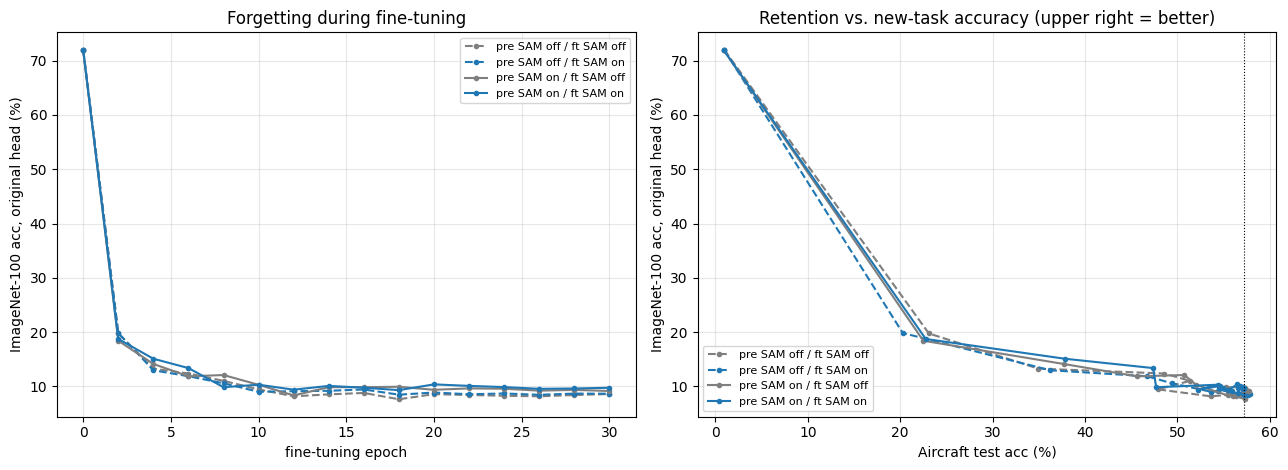

저장: /kaggle/working/exp_adamw


In [9]:
# ============ 셀 9: 결과 표 + 그림 ============
import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(RES)

# 같은 Aircraft 정확도 지점에서 비교 (덜 배워서 덜 잊은 것을 걸러내기)
target = min(max(r['air_acc'] for r in FT_LOG[n]) for n in df.name)
def retained_at(n):
    for r in FT_LOG[n]:
        if r['air_acc'] >= target: return r['imnet_retained']
    return float('nan')
df['matched_retained'] = df.name.map(retained_at)
df['matched_drop'] = df.imnet_before - df.matched_retained

cols = ['name', 'aircraft_acc', 'imnet_before', 'imnet_after', 'retained_drop', 'matched_drop',
        'probe_before', 'probe_after', 'recoverable_drop', 'cka', 'delta_rel']
display(df[cols].round(3))
df.to_csv(f'{OUT}/results.csv', index=False)

print(f'\n[비교 기준] Aircraft 정확도 {target:.2f}%에 처음 도달한 시점의 망각량 = matched_drop')
print('\n===== 핵심: 사전학습 decay-SAM이 망각을 줄였는가 =====')
for ft, label in [('ft_off', '파인튜닝 SAM 끔'), ('ft_sam', '파인튜닝 SAM 켬')]:
    a = df[(df.pre == 'pre_off') & (df.ft == ft)].iloc[0]
    b = df[(df.pre == 'pre_sam') & (df.ft == ft)].iloc[0]
    print(f'\n[{label}]')
    print(f'  원래 head 망각      : 없음 {a.retained_drop:6.2f}%p → 있음 {b.retained_drop:6.2f}%p  (줄어든 양 {a.retained_drop-b.retained_drop:+.2f}%p)')
    print(f'  같은 Aircraft 지점  : 없음 {a.matched_drop:6.2f}%p → 있음 {b.matched_drop:6.2f}%p  (줄어든 양 {a.matched_drop-b.matched_drop:+.2f}%p)')
    print(f'  probe(정보 손실)    : 없음 {a.recoverable_drop:6.2f}%p → 있음 {b.recoverable_drop:6.2f}%p  (줄어든 양 {a.recoverable_drop-b.recoverable_drop:+.2f}%p)')
    print(f'  Aircraft 정확도     : 없음 {a.aircraft_acc:6.2f}%  → 있음 {b.aircraft_acc:6.2f}%')
print('\n※ seed 1개 결과. 차이가 1%p 안쪽이면 노이즈일 수 있음.')

label = {'pre_off__ft_off': 'pre SAM off / ft SAM off', 'pre_off__ft_sam': 'pre SAM off / ft SAM on',
         'pre_sam__ft_off': 'pre SAM on / ft SAM off',  'pre_sam__ft_sam': 'pre SAM on / ft SAM on'}
style = {'pre_off__ft_off': ('tab:gray', '--'), 'pre_off__ft_sam': ('tab:blue', '--'),
         'pre_sam__ft_off': ('tab:gray', '-'),  'pre_sam__ft_sam': ('tab:blue', '-')}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for n, h in FT_LOG.items():
    c, ls = style[n]
    ep = [r['epoch'] for r in h]; ret = [r['imnet_retained'] for r in h]; air = [r['air_acc'] for r in h]
    ax[0].plot(ep, ret, color=c, ls=ls, marker='o', ms=3, label=label[n])
    ax[1].plot(air, ret, color=c, ls=ls, marker='o', ms=3, label=label[n])
ax[0].set_xlabel('fine-tuning epoch'); ax[0].set_ylabel('ImageNet-100 acc, original head (%)')
ax[0].set_title('Forgetting during fine-tuning')
ax[1].axvline(target, color='k', lw=0.8, ls=':')
ax[1].set_xlabel('Aircraft test acc (%)'); ax[1].set_ylabel('ImageNet-100 acc, original head (%)')
ax[1].set_title('Retention vs. new-task accuracy (upper right = better)')
for a in ax: a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT}/forgetting.png', dpi=150); plt.show()
print('저장:', OUT)